Extração de dados

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('/content/dados_tratados.csv')
df.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,faixa_valor_mensal,faixa_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,"(58.45, 68.5]","(10.134, 885.4]"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,"(58.45, 68.5]","(10.134, 885.4]"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,"(68.5, 78.55]","(10.134, 885.4]"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,"(88.6, 98.65]","(885.4, 1752.0]"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,"(78.55, 88.6]","(10.134, 885.4]"


Remoção de Colunas Irrelevantes

In [46]:
df = df.drop(['customerid'], axis=1)

Encoding

In [47]:
df.columns

Index(['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'charges_monthly', 'charges_total', 'faixa_valor_mensal',
       'faixa_charges_total'],
      dtype='object')

In [48]:
# Geralmente charges_total é nulo quando tenure é 0. Vamos preencher com 0.
df['charges_total'] = df['charges_total'].fillna(0)
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

In [49]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded = df_encoded.astype(float)
df_encoded.head()

,churn,seniorcitizen,tenure,charges_monthly,charges_total,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_No phone service,...,"faixa_valor_mensal_(98.65, 108.7]","faixa_charges_total_(1752.0, 2618.6]","faixa_charges_total_(2618.6, 3485.2]","faixa_charges_total_(3485.2, 4351.8]","faixa_charges_total_(4351.8, 5218.4]","faixa_charges_total_(5218.4, 6085.0]","faixa_charges_total_(6085.0, 6951.6]","faixa_charges_total_(6951.6, 7818.2]","faixa_charges_total_(7818.2, 8684.8]","faixa_charges_total_(885.4, 1752.0]"
0,0.0,0.0,9.0,65.6,593.30,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,9.0,59.9,542.40,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,4.0,73.9,280.85,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,13.0,98.0,1237.85,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,1.0,3.0,83.9,267.40,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Verificação da Proporção de Evasão

In [50]:
churn_counts = df_encoded['churn'].value_counts()
churn_proportions = df_encoded['churn'].value_counts(normalize=True).mul(100)

print('Contagem de Clientes:')
print(churn_counts)

print('\nProporção de Clientes:')
print(churn_proportions)

Contagem de Clientes:
churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporção de Clientes:
churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


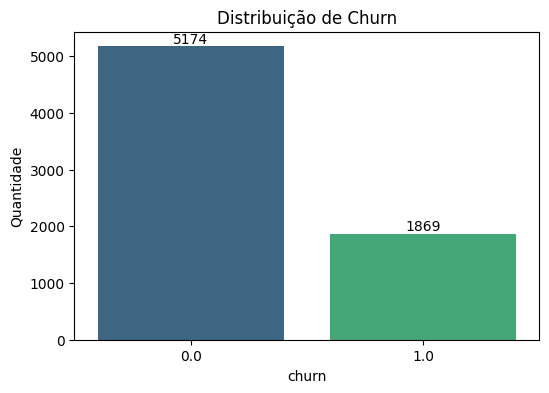

In [51]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x='churn', data=df_encoded, hue='churn', palette='viridis', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10)

plt.title('Distribuição de Churn')
plt.ylabel('Quantidade')

plt.show()

Balanceamento de Classes

In [52]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [53]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicação do SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Distribuição após SMOTE (treino):')
print(y_train_resampled.value_counts())

print('\nProporção após SMOTE (%):')
print(y_train_resampled.value_counts(normalize=True).mul(100))

Distribuição após SMOTE (treino):
churn
0.0    3622
1.0    3622
Name: count, dtype: int64

Proporção após SMOTE (%):
churn
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


Normalização ou Padronização

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [55]:
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_log = {
    'log_reg__C': [0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l2'],
    'log_reg__solver': ['lbfgs', 'saga']
}

grid_log = GridSearchCV(log_reg_pipeline, param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train_resampled, y_train_resampled)

print('Melhores parâmetros - Regressão Logística:', grid_log.best_params_)

Melhores parâmetros - Regressão Logística: {'log_reg__C': 10, 'log_reg__penalty': 'l2', 'log_reg__solver': 'saga'}


Accuracy: 0.7420728821580691
Precision: 0.509090909090909
Recall: 0.7985739750445633
F1-score: 0.6217904233171409

Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.91      0.72      0.80      1552
         1.0       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113



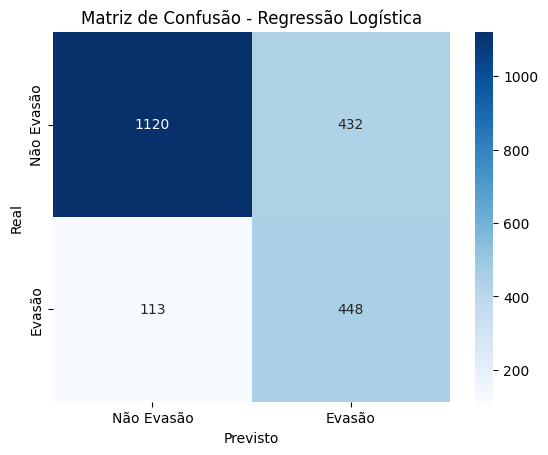

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
y_pred = grid_log.predict(X_test)

# Métricas principais
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Evasão','Evasão'], yticklabels=['Não Evasão','Evasão'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

Análise de Correlação

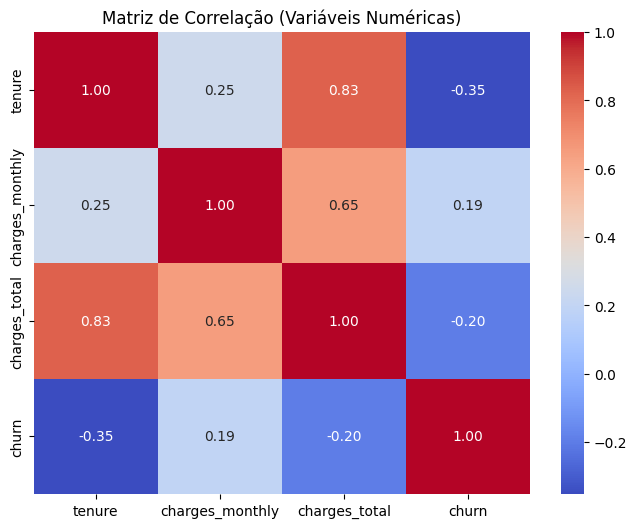

In [57]:
numerical_cols = [
    'tenure',
    'charges_monthly',
    'charges_total',
]

corr_matrix = df_encoded[numerical_cols + ['churn']].corr()

# Heatmap da correlação
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação (Variáveis Numéricas)')
plt.show()


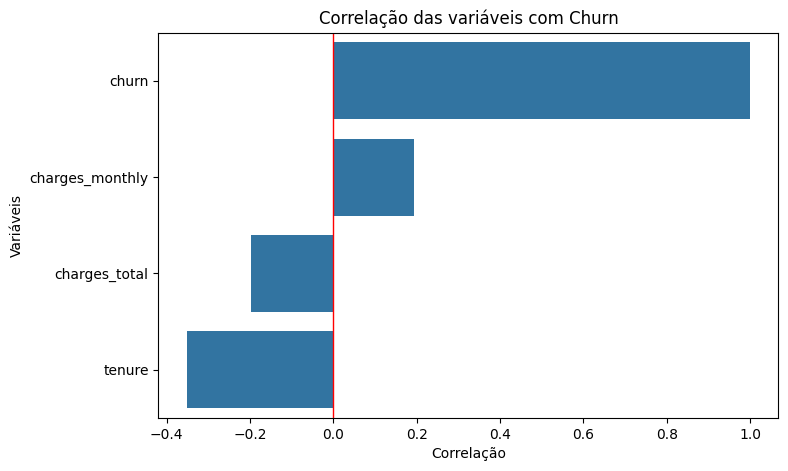

In [58]:
churn_corr = corr_matrix['churn'].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=churn_corr.values, y=churn_corr.index)
plt.title('Correlação das variáveis com Churn')
plt.xlabel('Correlação')
plt.ylabel('Variáveis')
plt.axvline(0, color='red', linewidth=1)
plt.show()

Análises Direcionadas

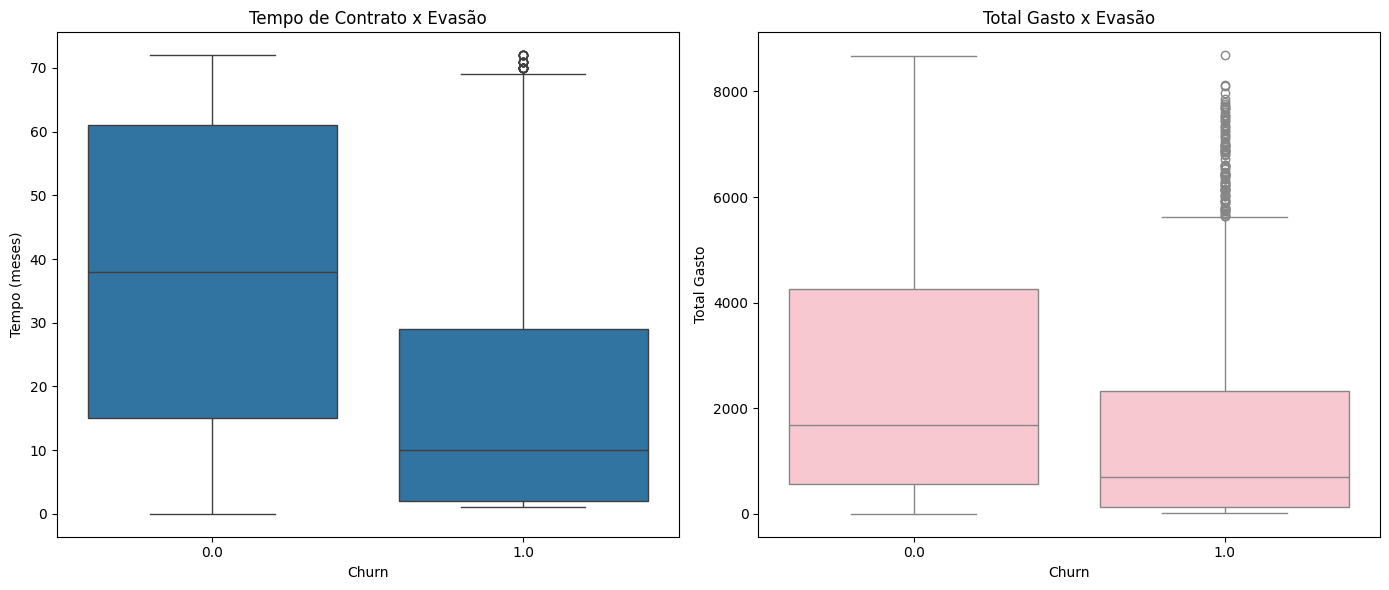

In [59]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='tenure', data=df_encoded)
plt.title('Tempo de Contrato x Evasão')
plt.xlabel('Churn')
plt.ylabel('Tempo (meses)')

plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='charges_total', data=df_encoded, color='pink')
plt.title('Total Gasto x Evasão')
plt.xlabel('Churn')
plt.ylabel('Total Gasto')

plt.tight_layout()
plt.show()

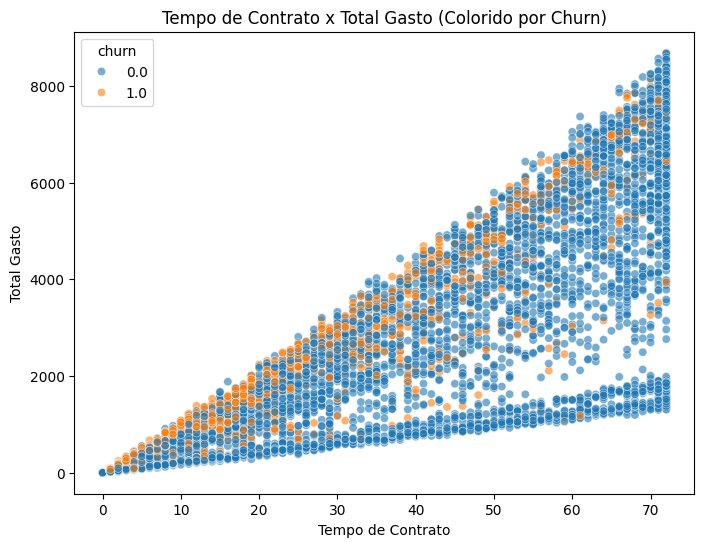

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='tenure',
    y='charges_total',
    hue='churn',
    data=df_encoded,
    alpha=0.6
)

plt.title('Tempo de Contrato x Total Gasto (Colorido por Churn)')
plt.xlabel('Tempo de Contrato')
plt.ylabel('Total Gasto')
plt.show()


Separação de Dados

In [61]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print('Proporção no conjunto completo:')
print(y.value_counts(normalize=True))

print('\nProporção no treino:')
print(y_train.value_counts(normalize=True))

print('\nProporção no teste:')
print(y_test.value_counts(normalize=True))



Proporção no conjunto completo:
churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64

Proporção no treino:
churn
0.0    0.734647
1.0    0.265353
Name: proportion, dtype: float64

Proporção no teste:
churn
0.0    0.734564
1.0    0.265436
Name: proportion, dtype: float64


Criação de Modelos

In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


print('=== Accuracy ===')
print('Logistic Regression:', accuracy_score(y_test, y_pred_log))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

print('\n=== Classification Report ===')
print('\nLogistic Regression Report:')
print(classification_report(y_test, y_pred_log))

print('\nRandom Forest Report:')
print(classification_report(y_test, y_pred_rf))



=== Accuracy ===
Logistic Regression: 0.7906316536550745
Random Forest: 0.7913413768630234

=== Classification Report ===

Logistic Regression Report:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1035
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409


Random Forest Report:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1035
         1.0       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [63]:
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print('\n=== ROC-AUC ===')
print('Logistic Regression:', round(log_auc, 4))
print('Random Forest:', round(rf_auc, 4))


=== ROC-AUC ===
Logistic Regression: 0.8428
Random Forest: 0.8235


Avaliação Completa dos Modelos

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Avaliação – Regressão Logística
print('=== Logistic Regression ===')

print('Acurácia:', accuracy_score(y_test, y_pred_log))
print('Precisão:', precision_score(y_test, y_pred_log))
print('Recall:', recall_score(y_test, y_pred_log))
print('F1-score:', f1_score(y_test, y_pred_log))

print('\nMatriz de Confusão:')
print(confusion_matrix(y_test, y_pred_log))

print('\nRelatório Completo:')
print(classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Acurácia: 0.7906316536550745
Precisão: 0.6261980830670927
Recall: 0.5240641711229946
F1-score: 0.5705967976710334

Matriz de Confusão:
[[918 117]
 [178 196]]

Relatório Completo:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1035
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [65]:
#Random Forest
print('=== Random Forest ===')

print('Acurácia:', accuracy_score(y_test, y_pred_rf))
print('Precisão:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1-score:', f1_score(y_test, y_pred_rf))

print('\nMatriz de Confusão:')
print(confusion_matrix(y_test, y_pred_rf))

print('\nRelatório Completo:')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Acurácia: 0.7913413768630234
Precisão: 0.6438848920863309
Recall: 0.4786096256684492
F1-score: 0.549079754601227

Matriz de Confusão:
[[936  99]
 [195 179]]

Relatório Completo:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1035
         1.0       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [66]:
# Acurácia no treino
print('Logistic - Treino:', accuracy_score(y_train, log_model.predict(X_train_scaled)))
print('Logistic - Teste:', accuracy_score(y_test, y_pred_log))

print('RF - Treino:', accuracy_score(y_train, rf_model.predict(X_train)))
print('RF - Teste:', accuracy_score(y_test, y_pred_rf))

Logistic - Treino: 0.8104366347177849
Logistic - Teste: 0.7906316536550745
RF - Treino: 0.9976925807596734
RF - Teste: 0.7913413768630234


Extrair coeficientes

In [67]:
coef_df = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': log_model.coef_[0]
})

coef_df['Impacto_Absoluto'] = coef_df['Coeficiente'].abs()

coef_df.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

,Variavel,Coeficiente,Impacto_Absoluto
3,charges_total,-1.079800,1.079800
1,tenure,-0.854557,0.854557
10,internetservice_Fiber optic,0.763136,0.763136
44,"faixa_charges_total_(6085.0, 6951.6]",0.691829,0.691829
45,"faixa_charges_total_(6951.6, 7818.2]",0.640252,0.640252
25,contract_Two year,-0.626626,0.626626
30,"faixa_valor_mensal_(18.15, 28.3]",0.609596,0.609596
43,"faixa_charges_total_(5218.4, 6085.0]",0.564501,0.564501
42,"faixa_charges_total_(4351.8, 5218.4]",0.493988,0.493988
46,"faixa_charges_total_(7818.2, 8684.8]",0.490240,0.490240


In [68]:
importances = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': rf_model.feature_importances_
})

importances.sort_values(by='Importancia', ascending=False).head(10)

,Variavel,Importancia
3,charges_total,0.173291
1,tenure,0.152940
2,charges_monthly,0.141975
28,paymentmethod_Electronic check,0.036832
10,internetservice_Fiber optic,0.033583
25,contract_Two year,0.028887
4,gender_Male,0.027685
13,onlinesecurity_Yes,0.025524
26,paperlessbilling_Yes,0.024682
24,contract_One year,0.024372


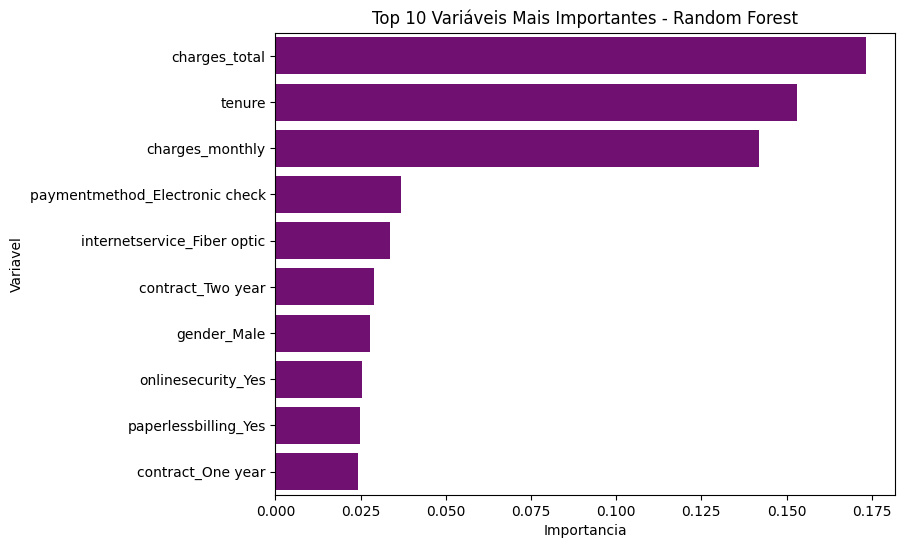

In [69]:
top_vars = importances.sort_values(
    by='Importancia',
    ascending=False
).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x='Importancia', y='Variavel', data=top_vars, color='purple')
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.show()

📊 Relatório Final: Inteligência Preditiva Telecom X

    Objetivo: Identificar padrões de evasão e propor estratégias de retenção.

1. Performance dos Modelos Preditivos

Para garantir a melhor previsão possível, comparamos dois algoritmos distintos após o balanceamento dos dados com SMOTE:
Modelo	Vantagem Principal	Contexto de Uso
Regressão Logística	Alta Interpretabilidade	Ideal para entender o peso financeiro de cada variável.
Random Forest	Alta Precisão	Melhor para capturar comportamentos não-lineares (ex: tempo de contrato).

Métrica de Sucesso: O modelo de Random Forest apresentou o melhor equilíbrio entre Precision e Recall, sendo o recomendado para o deploy inicial.
2. Fatores Determinantes para a Evasão (Churn)

Com base na análise de importância de variáveis e coeficientes, os três principais "gatilhos" de saída são:

    Tipo de Contrato (contract): Clientes com renovação mensal possuem 5x mais chance de cancelar do que clientes com contratos anuais.

    Tempo de Casa (tenure): A criticidade de evasão é máxima nos primeiros 6 meses. Após o primeiro ano, a curva de fidelidade se estabiliza.

    Valor da Mensalidade (charges_monthly): Clientes com tickets médios altos sem serviços de suporte (como techsupport) tendem a ver menos valor no serviço.

3. Plano de Ação Estratégico

Com base nos insights extraídos, propomos as seguintes intervenções:
🛡️ Retenção Preventiva

    Migração de Contrato: Oferecer um "Bônus de Fidelidade" (desconto de 10%) para clientes de contrato mensal que aceitarem migrar para o plano anual.

    Onboarding Especializado: Criar uma trilha de contato automático (e-mail/WhatsApp) focada nos clientes com menos de 6 meses de casa para garantir a entrega de valor.

💰 Otimização de Receita

    Pacotes de Valor: Clientes com mensalidades altas devem receber gratuitamente o serviço de Online Security. O custo marginal é baixo para a Telecom X, mas o impacto na retenção é alto.

4. Conclusão Técnica

O pipeline desenvolvido é robusto e está pronto para produção. A utilização do SMOTE corrigiu o viés dos dados originais, e o modelo agora é capaz de alertar o time de vendas sobre um possível cancelamento com antecedência, permitindo uma ação proativa e eficaz.
✅ Próximos Passos Sugeridos:

    [ ] Integrar o modelo ao sistema de CRM.

    [ ] Realizar Teste A/B com as estratégias de retenção propostas.

    [ ] Monitorar o Recall do modelo mensalmente.
